In [ ]:
import kagglehub
xhlulu_140k_real_and_fake_faces_path = kagglehub.dataset_download('xhlulu/140k-real-and-fake-faces')

print('Data source import complete.')


Data source import complete.


# Introduction to Deepfake Detection
Deepfakes are synthetic media (usually videos or images) created using deep learning techniques. They convincingly replace a person’s likeness in existing media with someone else’s, often leading to misinformation and potential harm. Detecting deepfakes is crucial for maintaining trust in visual content.

**on this project we will use dataset** ***140k Real and Fake Faces***

This dataset consists of all 70k REAL faces from the Flickr dataset collected by Nvidia, as well as 70k fake faces sampled from the 1 Million FAKE faces (generated by StyleGAN) that was provided by Bojan.

In this dataset, I convenient combined both dataset, resized all the images into 256px, and split the data into train, validation and test set. I also included some CSV files for convenience.

In [ ]:
import os
import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.applications import Xception
from sklearn.metrics import classification_report
from tensorflow.keras import Model


In [ ]:
train_data = pd.read_csv("/kaggle/input/140k-real-and-fake-faces/train.csv")
test_data  = pd.read_csv("/kaggle/input/140k-real-and-fake-faces/test.csv")
validation_data = pd.read_csv("/kaggle/input/140k-real-and-fake-faces/valid.csv")

In [ ]:
path="/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake"

In [ ]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


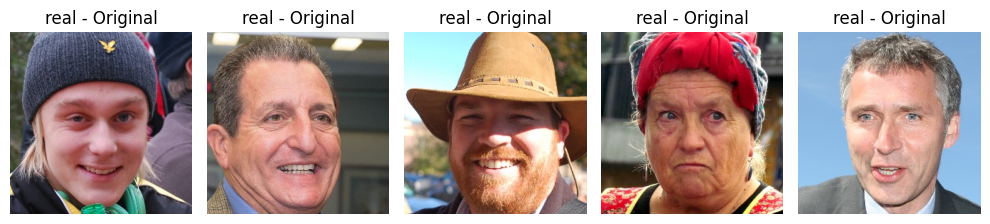

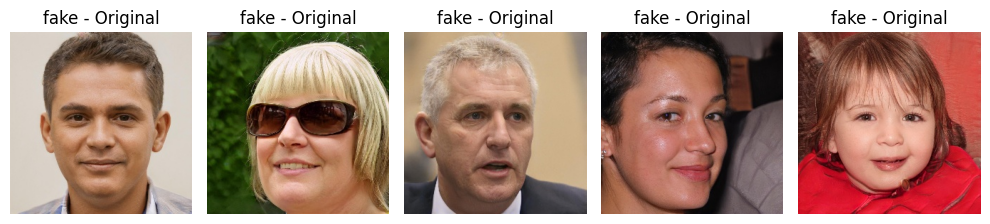

In [ ]:
def plot_original_images(path, set_, num_images=5):
    dir_ = os.path.join(path, 'train', set_)
    file_paths = [os.path.join(dir_, file_name) for file_name in os.listdir(dir_)[:num_images]]

    plt.figure(figsize=(10, 5))
    for i, file_path in enumerate(file_paths):
        img = load_img(file_path, target_size=(256, 256))  # Load the original image
        plt.subplot(2, num_images, i + 1)
        plt.imshow(img)
        plt.title(f"{set_} - Original")  # Set the title
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Call the function to plot original images for 'real' and 'fake' sets
plot_original_images(path, 'real')
plot_original_images(path, 'fake')

# Preprocessing and Augmentation
The ImageDataGenerator is a powerful tool for data augmentation and preprocessing in deep learning. It generates batches of augmented image data on-the-fly during training.

In [ ]:
gen_data = ImageDataGenerator(
    rescale=1./255.,
    preprocessing_function=preprocess_input,
    horizontal_flip=True,
    fill_mode='nearest',
    brightness_range=(0.8, 1.2),
    channel_shift_range=20,
)

In [ ]:
train_data_generator = gen_data.flow_from_dataframe(
    dataframe=train_data,
    directory=path,
    x_col ='path',
    y_col ='label_str',
    color_mode="rgb",
    target_size=(256, 256),
    class_mode="binary",
    batch_size=32,
    shuffle = True
)

Found 100000 validated image filenames belonging to 2 classes.


In [ ]:
validation_data_generator = gen_data.flow_from_dataframe(
    dataframe=validation_data,
    directory=path,
    x_col ='path',
    y_col ='label_str',
    color_mode="rgb",
    target_size=(256, 256),
    class_mode="binary",
    batch_size=32,
    shuffle = True
)


test_data_generator = gen_data.flow_from_dataframe(
    dataframe=test_data,
    directory=path,
    x_col ='path',
    y_col ='label_str',
    color_mode="rgb",
    target_size=(256, 256),
    class_mode="binary",
    batch_size=32,
    shuffle = False
)


Found 20000 validated image filenames belonging to 2 classes.
Found 20000 validated image filenames belonging to 2 classes.


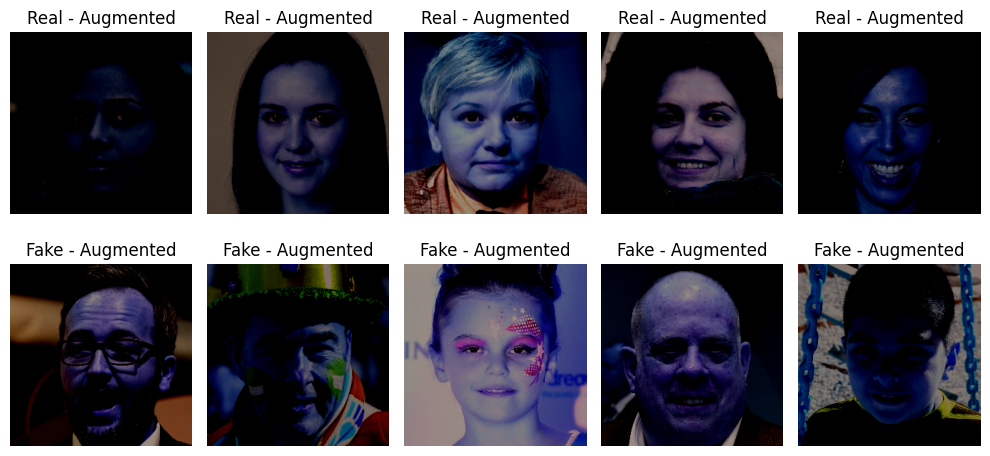

In [ ]:
images, labels = next(train_data_generator)

real_images = images[labels == 0]
fake_images = images[labels == 1]

# Plot 5 real/fake images
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(2, 5, i + 1)
    plt.imshow(real_images[i])
    plt.title("Real - Augmented")
    plt.axis('off')
for i in range(5):
    plt.subplot(2, 5, i + 6)
    plt.imshow(fake_images[i])
    plt.title("Fake - Augmented")
    plt.axis('off')

plt.tight_layout()
plt.show()


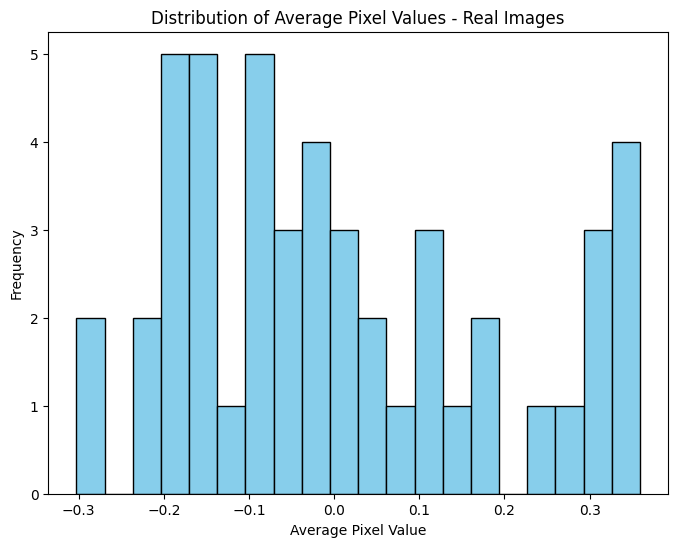

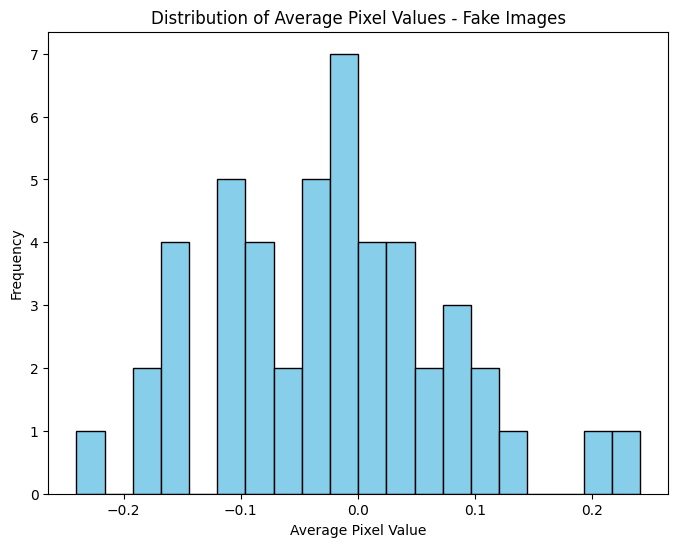

In [ ]:
def plot_image_distribution(images, title):
    image_means = np.mean(images, axis=(1, 2))
    image_means = image_means.flatten()
    plt.figure(figsize=(8, 6))
    plt.hist(image_means, bins=20, color='skyblue', edgecolor='black')
    plt.title(f'Distribution of Average Pixel Values - {title}')
    plt.xlabel('Average Pixel Value')
    plt.ylabel('Frequency')
    plt.show()

images, labels = next(train_data_generator)
real_images = images[labels == 0]
fake_images = images[labels == 1]
plot_image_distribution(real_images, 'Real Images')
plot_image_distribution(fake_images, 'Fake Images')

# Visualization

In [ ]:
labels = train_data_generator.class_indices
class_names = list(labels.keys())
print('class names:',class_names)

class names: ['fake', 'real']


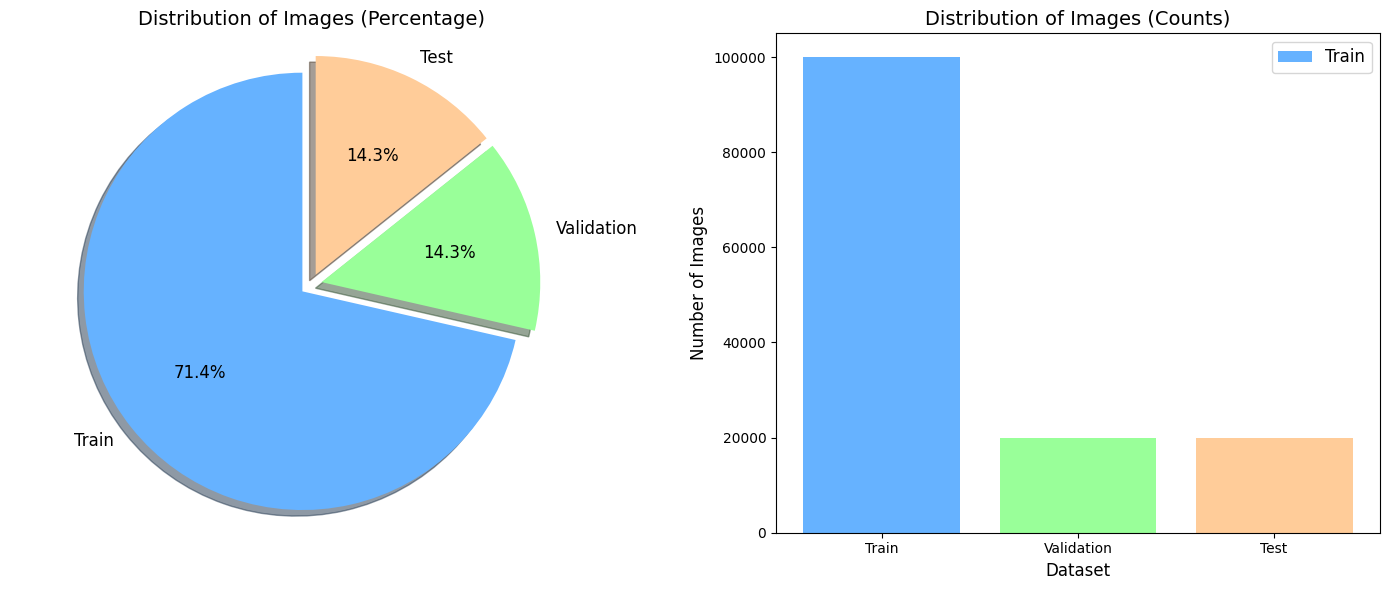

In [ ]:
labels = ["Train", "Validation", "Test"]
counts = [len(train_data), len(validation_data), len(test_data)]
colors = ['#66b2ff', '#99ff99', '#ffcc99']
explode = (0.05, 0.05, 0.05)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.pie(counts, labels=labels, autopct="%1.1f%%", colors=colors, explode=explode,
        shadow=True, startangle=90, textprops={'fontsize': 12})
ax1.set_title("Distribution of Images (Percentage)", fontsize=14)
ax1.axis('equal')

x = labels
y = counts
ax2.bar(x, y, color=colors)
ax2.set_xlabel('Dataset', fontsize=12)
ax2.set_ylabel('Number of Images', fontsize=12)
ax2.set_title('Distribution of Images (Counts)', fontsize=14)

plt.legend(labels, loc="best", fontsize=12)

plt.tight_layout()

plt.show()

# Convolutional Neural Networks (CNNs)
CNNs have been widely used for image classification tasks. They excel at learning hierarchical features from raw pixel data. In the context of deepfake detection, CNNs can analyze patterns and features in images to distinguish between real and manipulated content.

In [ ]:
model_cnn = Sequential()

model_cnn.add(Conv2D(32,kernel_size=(3, 3), activation='relu', input_shape=(256, 256, 3)))
model_cnn.add(MaxPooling2D((2, 2)))
model_cnn.add(Conv2D(64, (3, 3), activation='relu'))
model_cnn.add(MaxPooling2D((2, 2)))
model_cnn.add(Conv2D(64, (3, 3), activation='relu'))
model_cnn.add(MaxPooling2D((2, 2)))
model_cnn.add(Dropout(0.2))
model_cnn.add(Flatten())
model_cnn.add(Dense(64, activation='relu'))
model_cnn.add(Dropout(0.2))
model_cnn.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,742,849 (14.28 MB)

 Trainable params: 3,742,849 (14.28 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_cnn.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [ ]:
with tf.device('/GPU:0'):
    history = model_cnn.fit(train_data_generator, epochs=20, validation_data=validation_data_generator)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1148s 365ms/step - accuracy: 0.6808 - loss: 0.5791 - val_accuracy: 0.8412 - val_loss: 0.3584
Epoch 2/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 707s 226ms/step - accuracy: 0.8486 - loss: 0.3473 - val_accuracy: 0.8928 - val_loss: 0.2706
Epoch 3/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 704s 225ms/step - accuracy: 0.8895 - loss: 0.2669 - val_accuracy: 0.9183 - val_loss: 0.2052
Epoch 4/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 698s 223ms/step - accuracy: 0.9085 - loss: 0.2233 - val_accuracy: 0.9277 - val_loss: 0.1861
Epoch 5/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 709s 227ms/step - accuracy: 0.9215 - loss: 0.1967 - val_accuracy: 0.9352 - val_loss: 0.1700
Epoch 6/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 711s 227ms/step - accuracy: 0.9333 - loss: 0.1700 - val_accuracy: 0.9409 - val_loss: 0.1562
Epoch 7/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 722s 231ms/step - accuracy: 0.9384 - loss: 0.1584 - val_accuracy: 0.9470 - val_loss: 0.1418
Epoch 8/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 715s 229ms/step - a

In [ ]:
test_loss, test_accuracy = model_cnn.evaluate(test_data_generator)
print(f'Loss: {test_loss}, Accuracy: {test_accuracy}')

625/625 ━━━━━━━━━━━━━━━━━━━━ 191s 306ms/step - accuracy: 0.9487 - loss: 0.1277
Loss: 0.10422536730766296, Accuracy: 0.9598000049591064


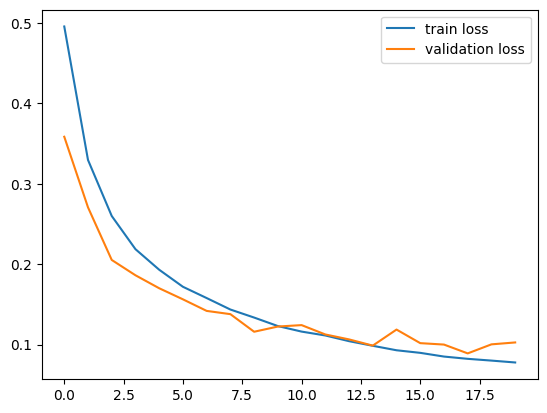

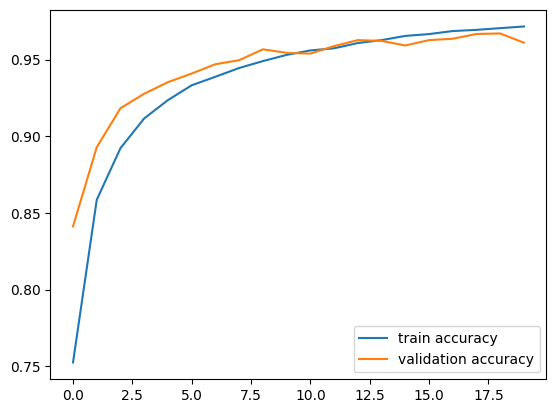

In [ ]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.legend()
plt.show()


plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.legend()
plt.show()


625/625 ━━━━━━━━━━━━━━━━━━━━ 117s 187ms/step


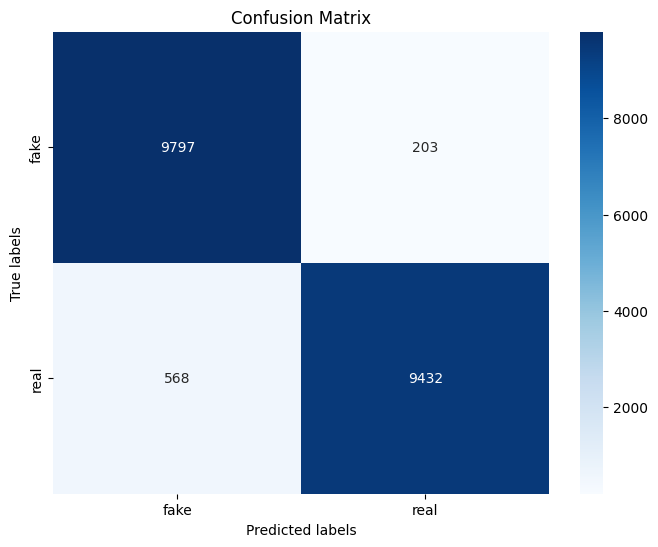

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

predictions = model_cnn.predict(test_data_generator)
predicted_labels = np.where(predictions > 0.5, 1, 0)
true_labels = test_data_generator.classes

conf_matrix = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_data_generator.class_indices,
            yticklabels=test_data_generator.class_indices)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
class_names = list(test_data_generator.class_indices.keys())
report = classification_report(true_labels, predicted_labels, target_names=class_names)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

        fake       0.95      0.98      0.96     10000
        real       0.98      0.94      0.96     10000

    accuracy                           0.96     20000
   macro avg       0.96      0.96      0.96     20000
weighted avg       0.96      0.96      0.96     20000



# XceptionNet
XceptionNet is a deep learning architecture based on CNNs. It was designed to improve the efficiency of feature extraction by replacing standard convolutional layers with depthwise separable convolutions. XceptionNet has been successfully applied to various computer vision tasks, including deepfake detection.

In [ ]:
base_model = Xception(weights='imagenet',include_top=False,input_shape=(256, 256, 3))


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
for layer in base_model.layers:
    layer.trainable = False

Xception_model = Sequential()
Xception_model.add(base_model)
Xception_model.add(Flatten())
Xception_model.add(BatchNormalization())
Xception_model.add(Dense(256, activation='relu'))
Xception_model.add(Dropout(0.5))
Xception_model.add(Dense(128, activation='relu'))
Xception_model.add(Dropout(0.5))
Xception_model.add(BatchNormalization())
Xception_model.add(Dense(1, activation='sigmoid'))

Xception_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 8, 8, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 131072)         │       524,288 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    33,554,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,973,993 (209.71 MB)

 Trainable params: 33,850,113 (129.13 MB)

 Non-trainable params: 21,123,880 (80.58 MB)

In [ ]:
Xception_model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
with tf.device('/GPU:0'):
  history = Xception_model.fit(train_data_generator ,epochs = 20,validation_data= (validation_data_generator))
  print(history.history)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1248s 392ms/step - accuracy: 0.7231 - loss: 0.5604 - val_accuracy: 0.8267 - val_loss: 0.3812
Epoch 2/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 715s 229ms/step - accuracy: 0.8259 - loss: 0.3897 - val_accuracy: 0.8565 - val_loss: 0.3336
Epoch 3/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 712s 228ms/step - accuracy: 0.8502 - loss: 0.3459 - val_accuracy: 0.8748 - val_loss: 0.2997
Epoch 4/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 716s 229ms/step - accuracy: 0.8676 - loss: 0.3111 - val_accuracy: 0.8744 - val_loss: 0.2944
Epoch 5/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 714s 229ms/step - accuracy: 0.8812 - loss: 0.2838 - val_accuracy: 0.8876 - val_loss: 0.2705
Epoch 6/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 718s 230ms/step - accuracy: 0.8919 - loss: 0.2620 - val_accuracy: 0.8687 - val_loss: 0.3034
Epoch 7/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 702s 225ms/step - accuracy: 0.8992 - loss: 0.2429 - val_accuracy: 0.8961 - val_loss: 0.2526
Epoch 8/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 707s 226ms/step - a

In [ ]:
test_loss, test_accuracy = Xception_model.evaluate(test_data_generator)
print(f'Loss: {test_loss}, Accuracy: {test_accuracy}')

625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 81ms/step - accuracy: 0.9030 - loss: 0.2655
Loss: 0.22897519171237946, Accuracy: 0.9151999950408936


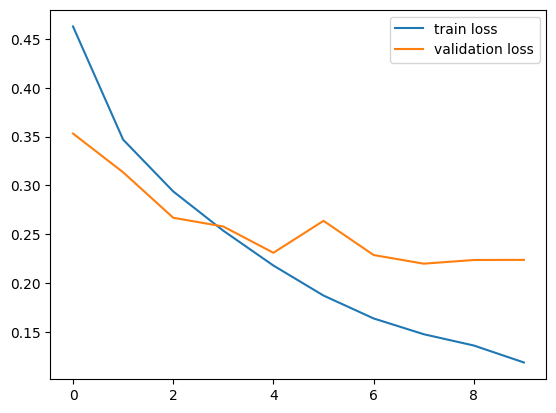

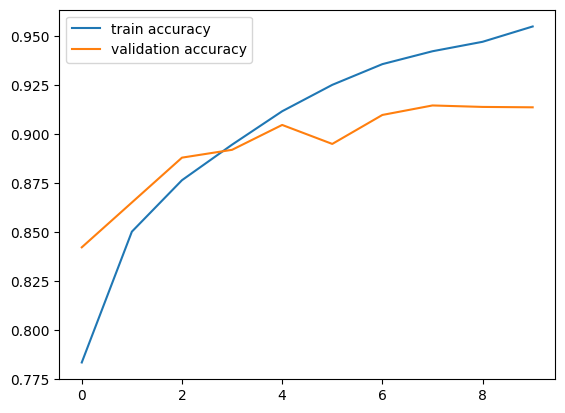

In [ ]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.legend()
plt.show()

625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 86ms/step


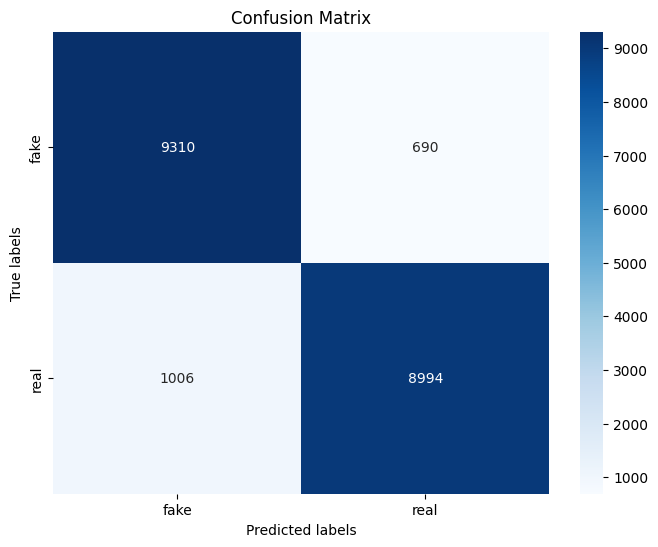

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

predictions = Xception_model.predict(test_data_generator)
predicted_labels = np.where(predictions > 0.5, 1, 0)
true_labels = test_data_generator.classes
conf_matrix = confusion_matrix(true_labels, predicted_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_data_generator.class_indices,
            yticklabels=test_data_generator.class_indices)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
class_names = list(test_data_generator.class_indices.keys())
report = classification_report(true_labels, predicted_labels, target_names=class_names)

print("Classification Report:")
print(report)


Classification Report:
              precision    recall  f1-score   support

        fake       0.90      0.93      0.92     10000
        real       0.93      0.90      0.91     10000

    accuracy                           0.92     20000
   macro avg       0.92      0.92      0.92     20000
weighted avg       0.92      0.92      0.92     20000

